<a href="https://colab.research.google.com/github/arentfall/cosmological-constraints-imposed-by-SZE-and-X-ray-of-clusters/blob/main/Cardassian_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Importation

In [ ]:
# for Google Colab
from google.colab import drive
drive.mount('/content/gdrive/')

Mounted at /content/gdrive/


In [ ]:
!pip install emcee
!pip install corner

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.4/47.4 kB 1.2 MB/s eta 0:00:00


In [ ]:
# Import the various libraries

## Data manipulation
import pandas as pd               # Tables and operations on imported data
import seaborn as sns             # Statistical visualisation
from scipy.integrate import cumulative_trapezoid
from scipy.integrate import quad
from scipy.interpolate import interp1d         # Compute a definite integral (from the Fortran library QUADPACK)
from scipy.special import beta               # Beta functions
import numpy as np
from astropy.cosmology import FlatLambdaCDM  # FLRW cosmology with a cosmological constant and no curvature, is efficient for the MCMC
import emcee                          # Is needed to perform MCMC

## Visualisation
import matplotlib.pyplot as plt
import corner

In [ ]:
# Importing data from the data_isothermal.txt file
# Please note that the separator is a comma
df=pd.read_csv('data_isothermal.txt',
               sep=',')

##
T = df['Delta_T0 [mK]']                   # SZE decrement
uT_plus = df['u(Delta_T0)_+']         # Upper uncertainty
uT_minus = df['u(Delta_T0)_-']       # Lower uncertainty
#
z = df['z']                                       # Redshift
#
DA = df['DA [Gpc]']                         # Angular diameter distance
uDA_minus = df['u(DA)_-']
uDA_plus = df['u(DA)_+']
#
SX0 = df['S_X0 [cnt cm-2 arcmin-2]']       # X-ray surface brightness
uSX0_plus = df['u(S_X0)_+']
uSX0_minus = df['u(S_X0)_-']
#
kT = df['kT [keV]']                                   # Temperature of the hot gas
ukT_plus = df['u(kT)_+']
ukT_minus = df['u(kT)_-']
#
theta = df['theta_c [arcsec]']                    # Angular core radius
utheta_plus = df['u(theta_c)_+']
utheta_minus = df['u(theta_c)_-']
#
lambda0 = df['Lambda [cnt cm3 s-1]']      # X-ray cooling function
ulambda0_plus = df['u(Lambda)_+']
ulambda0_minus = df['u(Lambda)_-']

In [ ]:
df.describe()

,S_X0 [cnt cm-2 arcmin-2],u(S_X0)_+,u(S_X0)_-,theta_c [arcsec],u(theta_c)_+,u(theta_c)_-,Delta_T0 [mK],u(Delta_T0)_+,u(Delta_T0)_-,kT [keV],u(kT)_+,u(kT)_-,DA [Gpc],u(DA)_+,u(DA)_-,z,Lambda [cnt cm3 s-1],u(Lambda)_+,u(Lambda)_-
count,38.000000,38.000000,38.000000,38.000000,38.000000,38.000000,38.000000,38.000000,38.000000,38.000000,38.000000,38.000000,38.000000,38.00000,38.000000,38.000000,3.800000e+01,3.800000e+01,3.800000e+01
mean,146.823684,2.768421,2.771053,29.820789,1.545000,1.416053,-1.442105,0.156053,0.159737,8.539474,0.578947,0.526316,1.238421,0.36500,0.300000,0.390053,2.612368e-15,4.868421e-17,4.710526e-17
std,363.225691,5.414999,5.525954,20.642705,1.801825,1.472287,0.877201,0.096857,0.100981,2.380045,0.395350,0.323565,0.697740,0.27446,0.214047,0.216330,3.499145e-16,2.672898e-17,2.598418e-17
min,2.600000,0.100000,0.100000,3.590000,0.010000,0.010000,-5.150000,0.050000,0.060000,4.700000,0.100000,0.100000,0.420000,0.08000,0.070000,0.142000,1.810000e-15,1.000000e-17,1.000000e-17
25%,12.800000,0.400000,0.400000,13.125000,0.700000,0.625000,-1.672500,0.092500,0.100000,6.650000,0.300000,0.300000,0.760000,0.20000,0.170000,0.218750,2.352500e-15,3.000000e-17,3.000000e-17
50%,24.850000,0.950000,0.900000,22.200000,1.300000,1.250000,-1.230000,0.125000,0.130000,8.250000,0.500000,0.450000,1.075000,0.26500,0.225000,0.306500,2.665000e-15,4.500000e-17,4.000000e-17
75%,60.500000,1.650000,1.700000,43.200000,1.600000,1.500000,-0.892500,0.177500,0.177500,9.875000,0.675000,0.675000,1.480000,0.40750,0.337500,0.544750,2.880000e-15,6.750000e-17,6.000000e-17
max,1837.000000,30.000000,30.000000,70.400000,10.600000,8.400000,-0.460000,0.580000,0.600000,14.800000,2.000000,1.600000,3.650000,1.27000,0.990000,0.890000,3.140000e-15,1.100000e-16,1.100000e-16


In [ ]:
# Load reconstructed angular distances
arrays = np.load("reconstructed_DA.npz")
DA_iso = arrays["arr_0"]
DA_calc = arrays["arr_1"]
print("File loaded!")
print("Isothermal DA: ",DA_iso, "\n", "Calculated DA: ",DA_calc)

File loaded!
Isothermal DA:  [0.86237482 0.40456193 0.88389952 0.89482304 0.58020532 0.19737558
 0.61021402 1.02383969 0.77408309 1.18539583 0.81500222 0.90329443
 1.19561968 0.46011156 1.72728579 0.45638657 0.79868547 0.47668615
 1.64692087 0.4871952  0.89316877 1.11       0.77961096 2.6027998
 0.26414316 0.55343508 0.72920658 0.47505481 1.08       0.74906737
 1.09683007 0.67412604 1.27426681 1.15651561 1.39       0.76
 0.84660817 2.51541496] 
 Calculated DA:  [0.91188103 0.4686375  1.00125743 1.15279657 0.74590978 0.18439718
 0.55881407 0.52444792 0.59369796 0.68838565 0.66441972 0.75365498
 0.81893938 0.89597073 2.08808782 0.40945738 0.29843505 0.52489838
 1.43127211 0.31256504 0.53687819 0.81758195 0.47125952 1.63485497
 0.43045485 0.9214644  0.60840647 0.33952074 0.77573808 0.96097416
 0.78751112 0.48844444 0.83885704 1.05909924 1.39       0.68472279
 0.71976141 1.42647503]


# Contour plot

In [ ]:
c = 299792.458                                      # [km/s], the speed of light in vacuum
H0 = 72.0                                              # Fixed value (Freedman et al. 2001) in km/s/Mpc
DA_err = (uDA_minus + uDA_plus) / 2    # Uncertainty mean, only statistical (Bonamente 2006)

## Combination of statistical contributions and systematic ones for the uncertainty (Table 3, Bonamente et al. 2006)
  # for the asphericity, the uncertainty can be up to 20 % (Puy et al. 2000) vs 15 % (Bonamente 2006)
DA_err_syst = (0.03 + 0.05 + 0.075 + 0.08 + 0.05) * DA.values
DA_err_total = np.sqrt(DA_err.values**2 + DA_err_syst**2)

  # Systematic Contributions (on DA, table 3): +3% Presence of radio halos, +5% X-ray absolute flux calibration (SX0),
  # +7.5% X-ray temperature calibration (kT), +8% SZE calibration

Reduced Chi2 = 1.01


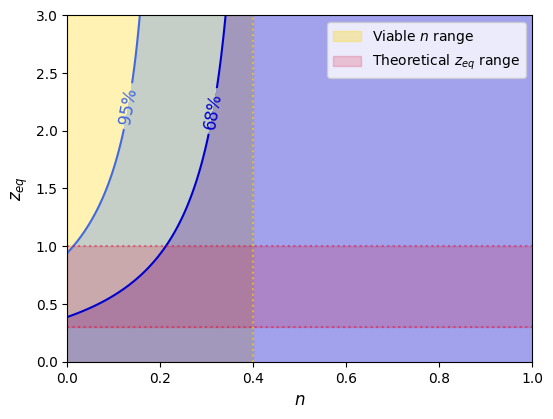

In [ ]:
## Confidence contour
n_range = np.linspace(0.0, 1.0, 100)
zeq_range = np.linspace(0.0, 3.0, 100)
NR, ZR = np.meshgrid(n_range, zeq_range)

##
def expansion_rate(z, z_eq, n):              # Freese 2002
  num_term = np.sqrt((1+z)**3 + (1+z_eq)**(3*(1-n)) * (1+z)**(3*n))
  den_term = np.sqrt(1 + (1+z_eq)**(3*(1-n)))
  return num_term / den_term

def theo_DA_Cardassian(z, z_eq, n):        # Freese 2002
  integral = lambda zeta: 1 / expansion_rate(zeta, z_eq, n)
  term_num = c * quad(integral, 0, z)[0]   # Integration by the Scipy module quad
  term_den = H0 * (1+z)
  da_theo = term_num / term_den                         # [Mpc]
  return da_theo / 1000                                         # [Gpc]

def Chi2_2D(z_eq, n, z_vals, DA_obs):
  DA_model = np.array([theo_DA_Cardassian(zi, z_eq, n) for zi in z_vals])
  chi2 = np.sum((DA_obs - DA_model)**2 / DA_err_total**2)
  return chi2

chi2_2d = np.zeros_like(ZR)
for i in range(len(zeq_range)):
    for j in range(len(n_range)):
        chi2_2d[i, j] = Chi2_2D(ZR[i, j], NR[i, j], z.values, DA.values)
##
plt.figure(figsize=(6, 4.5))
min_chi2 = np.min(chi2_2d)
delta_chi2 = chi2_2d - min_chi2

dof = len(z) - 2                                         # 2 parameters
chi2_red = min_chi2 / dof

print(f"Reduced Chi2 = {chi2_red:.2f}")      # If it is near 1, the model is correct

plt.axvspan(0.0, 0.4, color='gold', alpha=0.3, label=r'Viable $n$ range')
plt.axvline(0.0, color='gold', linestyle=':', alpha=0.6)
plt.axvline(0.4, color='gold', linestyle=':', alpha=0.6)

plt.contourf(NR, ZR, delta_chi2,
                       levels=[0, 2.30, 6.17],               # sigma 1 / 68 % ; sigma 2 / 95 %
                       colors=['mediumblue', 'cornflowerblue'], alpha=0.37)

contours = plt.contour(NR, ZR, delta_chi2, levels=[2.30, 6.17],
                       colors=['mediumblue', 'royalblue'], linewidths=1.5)

plt.axhspan(0.3, 1.0, color='crimson', alpha=0.2, label=r'Theoretical $z_{eq}$ range')
plt.axhline(0.3, color='crimson', linestyle=':', alpha=0.5)
plt.axhline(1.0, color='crimson', linestyle=':', alpha=0.5)

plt.clabel(contours, inline=True, fmt={2.30: '68%', 6.17: '95%'}, fontsize=12)
plt.xlabel(r'$n$ ', fontsize=12)
plt.ylabel(r'$z_{eq}$', fontsize=12)

plt.legend()
plt.show()

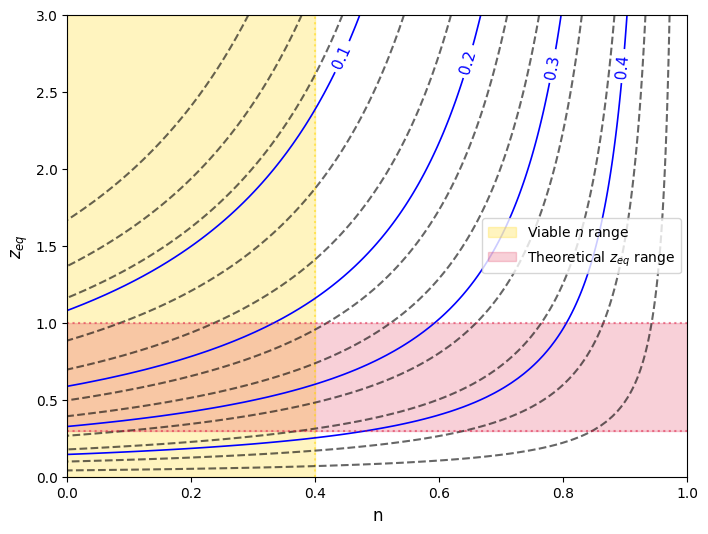

In [ ]:
n_vals = np.linspace(0, 1.0, 100)
zeq_vals = np.linspace(0, 3.0, 100)
N, Z = np.meshgrid(n_vals, zeq_vals)

# The equality parameter, fraction of the standard critical density today (Freese 2002)
F = 1.0 / (1.0 + (1.0 + Z)**(3.0 * (1.0 - N)))

plt.figure(figsize=(8, 6))
levels = [0.05, 0.07, 0.09, 0.13, 0.17, 0.23, 0.27 ,0.33, 0.38, 0.43, 0.47]
high_lvls = [0.1, 0.2, 0.3, 0.4]

plt.axvspan(0.0, 0.4, color='gold', alpha=0.25, label=r'Viable $n$ range')
plt.axvline(0.0, color='gold', linestyle=':', alpha=0.5)
plt.axvline(0.4, color='gold', linestyle=':', alpha=0.5)

contours = plt.contour(N, Z, F, levels=high_lvls, colors='blue', linewidths=1.2)
plt.contour(N, Z, F, levels=levels, colors="black", linestyles='--', alpha=0.6)
plt.clabel(contours, inline=True, fontsize=11, fmt='%1.1f')

plt.axhspan(0.3, 1.0, color='crimson', alpha=0.2, label=r'Theoretical $z_{eq}$ range')
plt.axhline(0.3, color='crimson', linestyle=':', alpha=0.5)
plt.axhline(1.0, color='crimson', linestyle=':', alpha=0.5)

plt.xlabel('n', fontsize=12)
plt.ylabel(r'$z_{eq}$', fontsize=12)
plt.legend()
plt.show()

Reduced Chi2 = 1.01


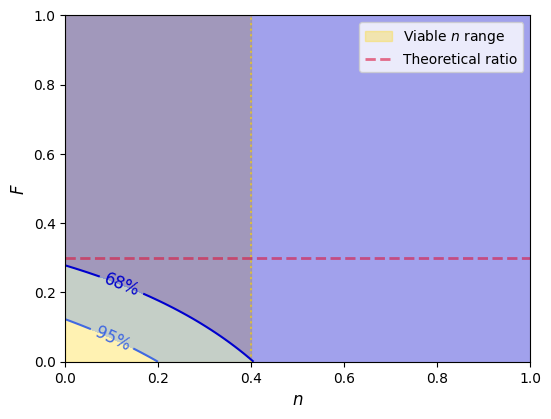

In [ ]:
## Confidence contour
F_range = np.linspace(0.0, 1.0, 100)
n_range = np.linspace(0.0, 1.0, 100)
FR, nR = np.meshgrid(F_range, n_range)

##
def expansion_rate(z, F, n):              # Freese 2002
  E_term = np.sqrt(F*(1+z)**3 + (1-F) * (1+z)**(3*n))
  return E_term

def theo_DA_Cardassian(z, F, n):        # Freese 2002
  integral = lambda zeta: 1 / expansion_rate(zeta, F, n)
  term_num = c * quad(integral, 0, z)[0]   # Integration by the Scipy module quad
  term_den = H0 * (1+z)
  da_theo = term_num / term_den                         # [Mpc]
  return da_theo / 1000                                         # [Gpc]

def Chi2_2D(F, n, z_vals, DA_obs):
  DA_model = np.array([theo_DA_Cardassian(zi, F, n) for zi in z_vals])
  chi2 = np.sum((DA_obs - DA_model)**2 / DA_err_total**2)
  return chi2

chi2_2d = np.zeros_like(FR)
for i in range(len(n_range)):
    for j in range(len(F_range)):
        chi2_2d[i, j] = Chi2_2D(FR[i, j], nR[i, j], z.values, DA.values)
##
plt.figure(figsize=(6, 4.5))
min_chi2 = np.min(chi2_2d)
delta_chi2 = chi2_2d - min_chi2

dof = len(z) - 2                                         # 2 parameters
chi2_red = min_chi2 / dof

print(f"Reduced Chi2 = {chi2_red:.2f}")      # If it is near 1, the model is correct

plt.axvspan(0.0, 0.4, color='gold', alpha=0.3, label=r'Viable $n$ range')
plt.axvline(0.0, color='gold', linestyle=':', alpha=0.6)
plt.axvline(0.4, color='gold', linestyle=':', alpha=0.6)

plt.axhline(0.3, color='crimson', linestyle='--', linewidth=2, alpha=0.6, label="Theoretical ratio")

plt.contourf(nR, FR, delta_chi2,
                       levels=[0, 2.30, 6.17],               # sigma 1 / 68 % ; sigma 2 / 95 %
                       colors=['mediumblue', 'cornflowerblue'], alpha=0.37)

contours = plt.contour(nR, FR, delta_chi2, levels=[2.30, 6.17],
                       colors=['mediumblue', 'royalblue'], linewidths=1.5)

plt.clabel(contours, inline=True, fmt={2.30: '68%', 6.17: '95%'}, fontsize=12)
plt.xlabel(r'$n$ ', fontsize=12)
plt.ylabel(r'$F$', fontsize=12)

plt.legend()
plt.show()

# MCMCs

100%|██████████| 5000/5000 [03:55<00:00, 21.23it/s]


H0 = 72.15 +/- [-6.81846714  9.78016239]
z_eq = 0.59 +/- [-0.21305742  0.27542834]
n = 0.22 +/- [-0.49002079  0.32121348]
sigma_int = 0.18 +/- [-0.08612634  0.0818656 ]
F (Density Ratio) = 0.256 +0.093 / -0.114


<Figure size 800x800 with 0 Axes>

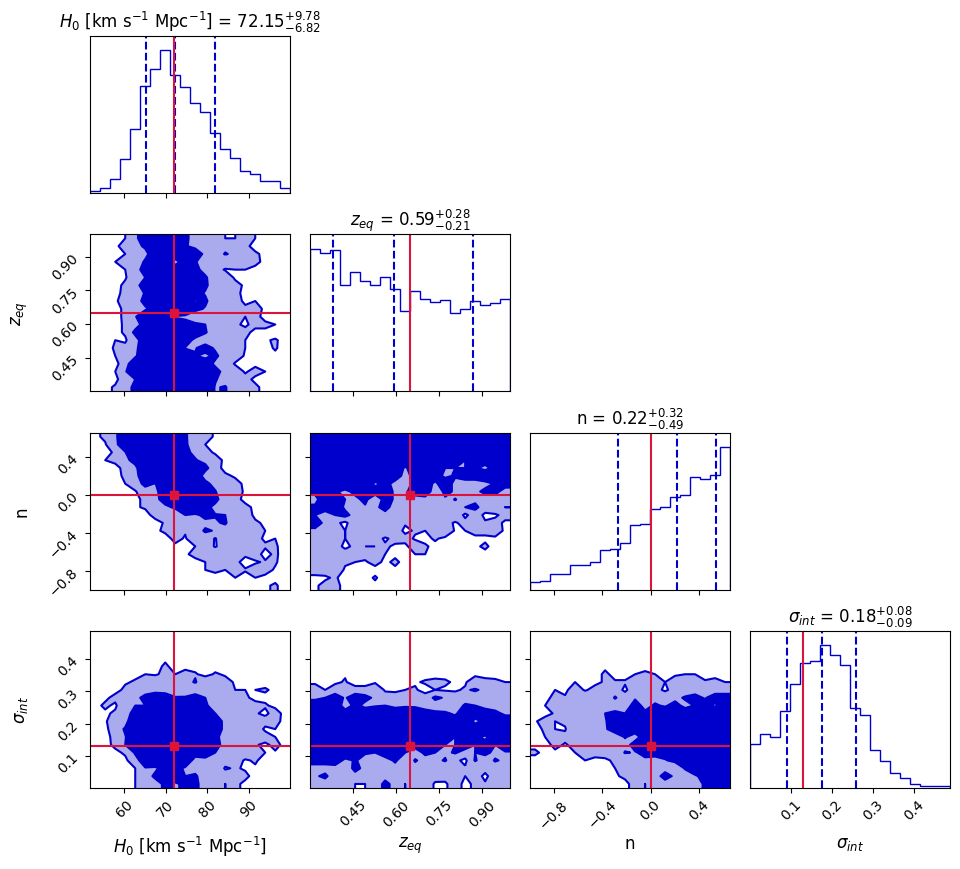

<Figure size 640x480 with 0 Axes>

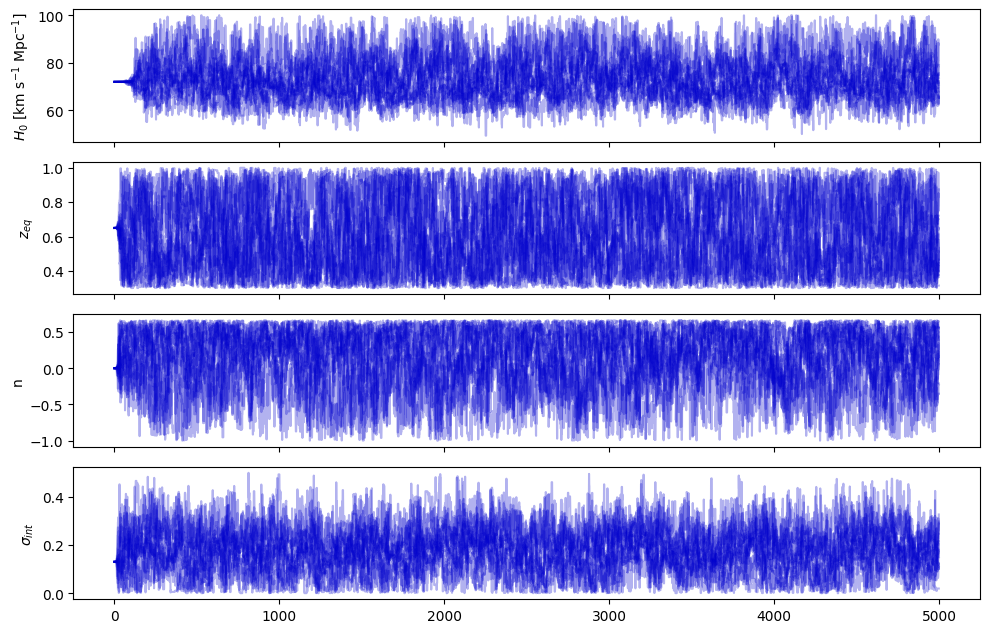

Autocorrelation times: [62.8403582  79.88830642 63.53779259 68.3419997 ]


In [ ]:
def expansion_rate(z, z_eq, n):              # Freese 2002
  num_term = np.sqrt((1+z)**3 + (1+z_eq)**(3*(1-n)) * (1+z)**(3*n))
  den_term = np.sqrt(1 + (1+z_eq)**(3*(1-n)))
  return num_term / den_term

def theo_DA_Cardassian(H0, z, z_eq, n):        # Freese 2002
  integral = lambda zeta: 1 / expansion_rate(zeta, z_eq, n)
  term_num = c * quad(integral, 0, z)[0]   # Integration by the Scipy module quad
  term_den = H0 * (1+z)
  da_theo = term_num / term_den                         # [Mpc]
  return da_theo / 1000                                         # [Gpc]

def lnlike(theta, z_vals, DA_obs, DA_err):
    H0, z_eq, n, sigma_int = theta
    DA_model = np.array([theo_DA_Cardassian(H0, zi, z_eq, n) for zi in z_vals])
    total_err2 = DA_err**2 + (sigma_int * DA_model)**2
    chi2 = np.sum((DA_obs - DA_model)**2 / total_err2)
    return -0.5 * (chi2 + np.sum(np.log(2 * np.pi * total_err2)))

def lnprior(theta):
    H0, z_eq, n, sigma_int = theta
    # Priors based on Freese 2002: n < 2/3 for acceleration
    if 40 < H0 < 100 and 0.3 < z_eq < 1.0 and -1.0 < n < 0.66 and 0.0 < sigma_int < 0.5:
        return 0.0
    return -np.inf

def lnprob(theta, z_vals, DA_obs, DA_err): # Metropolis-Hastings criterion
    lp = lnprior(theta)
    if not np.isfinite(lp):
        return -np.inf
    return lp + lnlike(theta, z_vals, DA_obs, DA_err)

ndim = 4                                      # Number of dimensions in the parameter space
nwalkers = 16                               # The number of walkers in the ensemble
initial = np.array([72, 0.65, 0.0, 0.13])            # Initial guess around LCDM
pos = initial + 1e-4 * np.random.randn(nwalkers, ndim)

z_vals = np.asarray(z)
DA_obs = np.asarray(DA)

sampler = emcee.EnsembleSampler(
    nwalkers, ndim, lnprob,
    args=(z_vals, DA_obs, DA_err_total))

sampler.run_mcmc(pos, 5000, progress=True)
samples = sampler.get_chain(discard=1000, thin=15, flat=True)

#
H0_samples, zeq_samples, n_samples, sigma_samples = samples[:,0], samples[:,1], samples[:,2], samples[:,3]

F_samples = 1.0 / (1.0 + (1.0 + zeq_samples)**(3.0 * (1.0 - n_samples)))
F_median = np.median(F_samples)
F_lower, F_upper = np.percentile(F_samples, [16, 84])

# Report results using median and 16th/84th percentiles as Bonamente 2006
print(f"H0 = {np.median(H0_samples):.2f} +/- {np.percentile(H0_samples, [16, 84]) - np.median(H0_samples)}")
print(f"z_eq = {np.median(zeq_samples):.2f} +/- {np.percentile(zeq_samples, [16, 84]) - np.median(zeq_samples)}")
print(f"n = {np.median(n_samples):.2f} +/- {np.percentile(n_samples, [16, 84]) - np.median(n_samples)}")
print(f"sigma_int = {np.median(sigma_samples):.2f} +/- {np.percentile(sigma_samples, [16, 84]) - np.median(sigma_samples)}")
print(f"F (Density Ratio) = {F_median:.3f} +{F_upper - F_median:.3f} / -{F_median - F_lower:.3f}")

# Corner Plot
plt.figure(figsize=(8, 8))
labels = [r"$H_0$ [km s$^{-1}$ Mpc$^{-1}$]", r"$z_{eq}$", r"n", r"$\sigma_{int}$"]
fig = corner.corner(samples, labels=labels, truths=[72, 0.65, 0.0, 0.13], show_titles=True,
    title_fmt=".2f", quantiles=[0.16, 0.5, 0.84], levels=(0.68, 0.95), color="mediumblue",
    truth_color="crimson", plot_datapoints=False, fill_contours=True, label_kwargs={"fontsize": 12})
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

##  Convergence test
  # We want the walkers to look like a "fuzzy caterpillar" (http://phoebe-project.org/, PHOEBE tutorial emcee.ipynb)
plt.figure()
fig, axes = plt.subplots(ndim, figsize=(10, 7), sharex=True)
for i in range(ndim):
    ax = axes[i]
    ax.plot(sampler.get_chain()[:, :, i], "mediumblue", alpha=0.3)
    ax.set_ylabel(labels[i])
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# We want our chain to be at least 50 times longer than the autocorrelation time (http://phoebe-project.org/, PHOEBE tutorial emcee.ipynb)
tau = sampler.get_autocorr_time()
print(f"Autocorrelation times: {tau}")

100%|██████████| 5000/5000 [03:45<00:00, 22.20it/s]


H0 = 84.95 +/- [-8.88307445  8.3197987 ]
z_eq = 0.61 +/- [-0.22269543  0.26779674]
n = 0.39 +/- [-0.3752245   0.19591527]
sigma_int = 0.29 +/- [-0.10009178  0.09509712]
F (Density Ratio) = 0.295 +0.067 / -0.095


<Figure size 800x800 with 0 Axes>

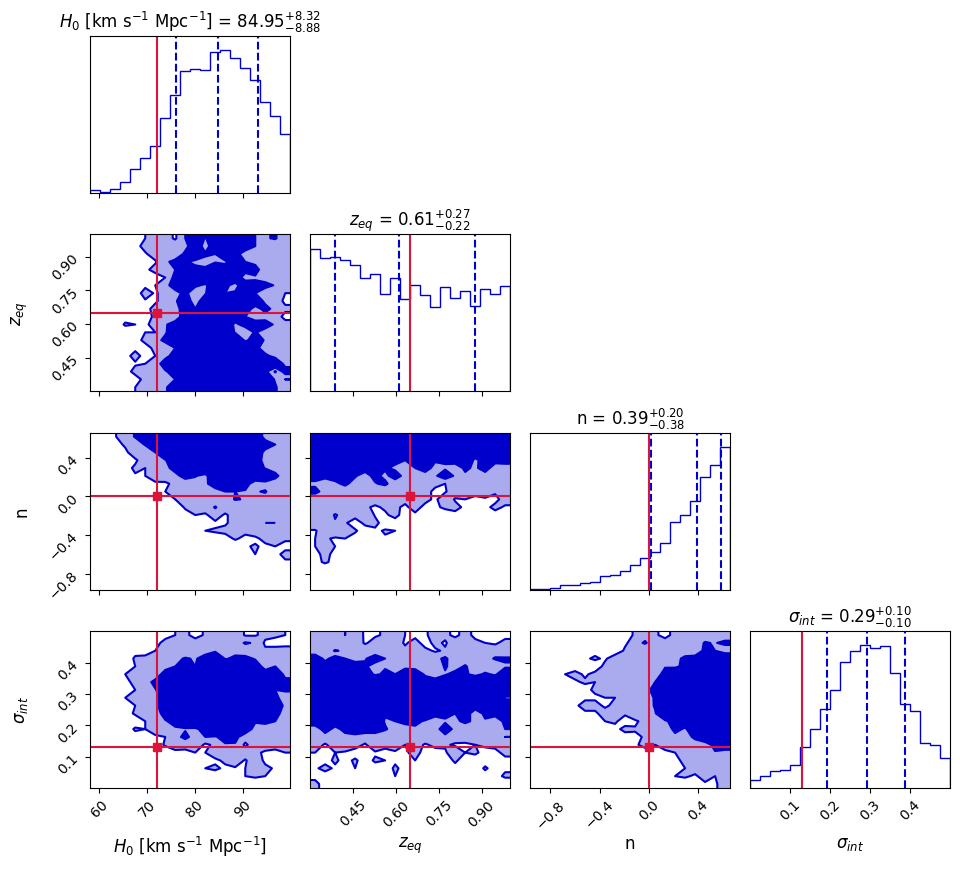

<Figure size 640x480 with 0 Axes>

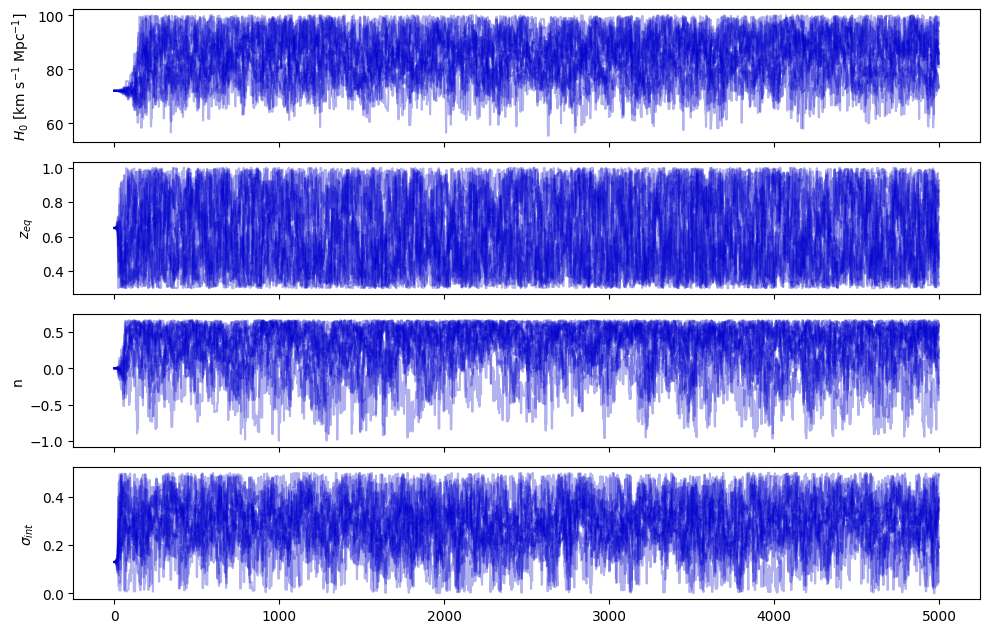

Autocorrelation times: [74.74808869 91.55335987 73.94471319 59.83286401]


In [ ]:
def expansion_rate(z, z_eq, n):              # Freese 2002
  num_term = np.sqrt((1+z)**3 + (1+z_eq)**(3*(1-n)) * (1+z)**(3*n))
  den_term = np.sqrt(1 + (1+z_eq)**(3*(1-n)))
  return num_term / den_term

def theo_DA_Cardassian(H0, z, z_eq, n):        # Freese 2002
  integral = lambda zeta: 1 / expansion_rate(zeta, z_eq, n)
  term_num = c * quad(integral, 0, z)[0]   # Integration by the Scipy module quad
  term_den = H0 * (1+z)
  da_theo = term_num / term_den                         # [Mpc]
  return da_theo / 1000                                         # [Gpc]

def lnlike(theta, z_vals, DA_obs, DA_err):
    H0, z_eq, n, sigma_int = theta
    DA_model = np.array([theo_DA_Cardassian(H0, zi, z_eq, n) for zi in z_vals])
    total_err2 = DA_err**2 + (sigma_int * DA_model)**2
    chi2 = np.sum((DA_obs - DA_model)**2 / total_err2)
    return -0.5 * (chi2 + np.sum(np.log(2 * np.pi * total_err2)))

def lnprior(theta):
    H0, z_eq, n, sigma_int = theta
    # Priors based on Freese 2002: n < 2/3 for acceleration
    if 40 < H0 < 100 and 0.3 < z_eq < 1.0 and -1.0 < n < 0.66 and 0.0 < sigma_int < 0.5:
        return 0.0
    return -np.inf

def lnprob(theta, z_vals, DA_obs, DA_err): # Metropolis-Hastings criterion
    lp = lnprior(theta)
    if not np.isfinite(lp):
        return -np.inf
    return lp + lnlike(theta, z_vals, DA_obs, DA_err)

ndim = 4                                      # Number of dimensions in the parameter space
nwalkers = 16                               # The number of walkers in the ensemble
initial = np.array([72, 0.65, 0.0, 0.13])            # Initial guess around LCDM
pos = initial + 1e-4 * np.random.randn(nwalkers, ndim)

z_vals = np.asarray(z)

sampler = emcee.EnsembleSampler(
    nwalkers, ndim, lnprob,
    args=(z_vals, DA_iso, DA_err_total))

sampler.run_mcmc(pos, 5000, progress=True)
samples = sampler.get_chain(discard=1000, thin=15, flat=True)

#
H0_samples, zeq_samples, n_samples, sigma_samples = samples[:,0], samples[:,1], samples[:,2], samples[:,3]

F_samples = 1.0 / (1.0 + (1.0 + zeq_samples)**(3.0 * (1.0 - n_samples)))
F_median = np.median(F_samples)
F_lower, F_upper = np.percentile(F_samples, [16, 84])

# Report results using median and 16th/84th percentiles as Bonamente 2006
print(f"H0 = {np.median(H0_samples):.2f} +/- {np.percentile(H0_samples, [16, 84]) - np.median(H0_samples)}")
print(f"z_eq = {np.median(zeq_samples):.2f} +/- {np.percentile(zeq_samples, [16, 84]) - np.median(zeq_samples)}")
print(f"n = {np.median(n_samples):.2f} +/- {np.percentile(n_samples, [16, 84]) - np.median(n_samples)}")
print(f"sigma_int = {np.median(sigma_samples):.2f} +/- {np.percentile(sigma_samples, [16, 84]) - np.median(sigma_samples)}")
print(f"F (Density Ratio) = {F_median:.3f} +{F_upper - F_median:.3f} / -{F_median - F_lower:.3f}")

# Corner Plot
plt.figure(figsize=(8, 8))
labels = [r"$H_0$ [km s$^{-1}$ Mpc$^{-1}$]", r"$z_{eq}$", r"n", r"$\sigma_{int}$"]
fig = corner.corner(samples, labels=labels, truths=[72, 0.65, 0.0, 0.13], show_titles=True,
    title_fmt=".2f", quantiles=[0.16, 0.5, 0.84], levels=(0.68, 0.95), color="mediumblue",
    truth_color="crimson", plot_datapoints=False, fill_contours=True, label_kwargs={"fontsize": 12})
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

##  Convergence test
  # We want the walkers to look like a "fuzzy caterpillar" (http://phoebe-project.org/, PHOEBE tutorial emcee.ipynb)
plt.figure()
fig, axes = plt.subplots(ndim, figsize=(10, 7), sharex=True)
for i in range(ndim):
    ax = axes[i]
    ax.plot(sampler.get_chain()[:, :, i], "mediumblue", alpha=0.3)
    ax.set_ylabel(labels[i])
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# We want our chain to be at least 50 times longer than the autocorrelation time (http://phoebe-project.org/, PHOEBE tutorial emcee.ipynb)
tau = sampler.get_autocorr_time()
print(f"Autocorrelation times: {tau}")

100%|██████████| 7300/7300 [05:28<00:00, 22.21it/s]


H0 = 94.66 +/- [-6.23309673  3.91513545]
z_eq = 0.60 +/- [-0.21216407  0.26427484]
n = 0.48 +/- [-0.24572337  0.12789541]
sigma_int = 0.20 +/- [-0.11112897  0.10737928]
F (Density Ratio) = 0.323 +0.055 / -0.076


<Figure size 800x800 with 0 Axes>

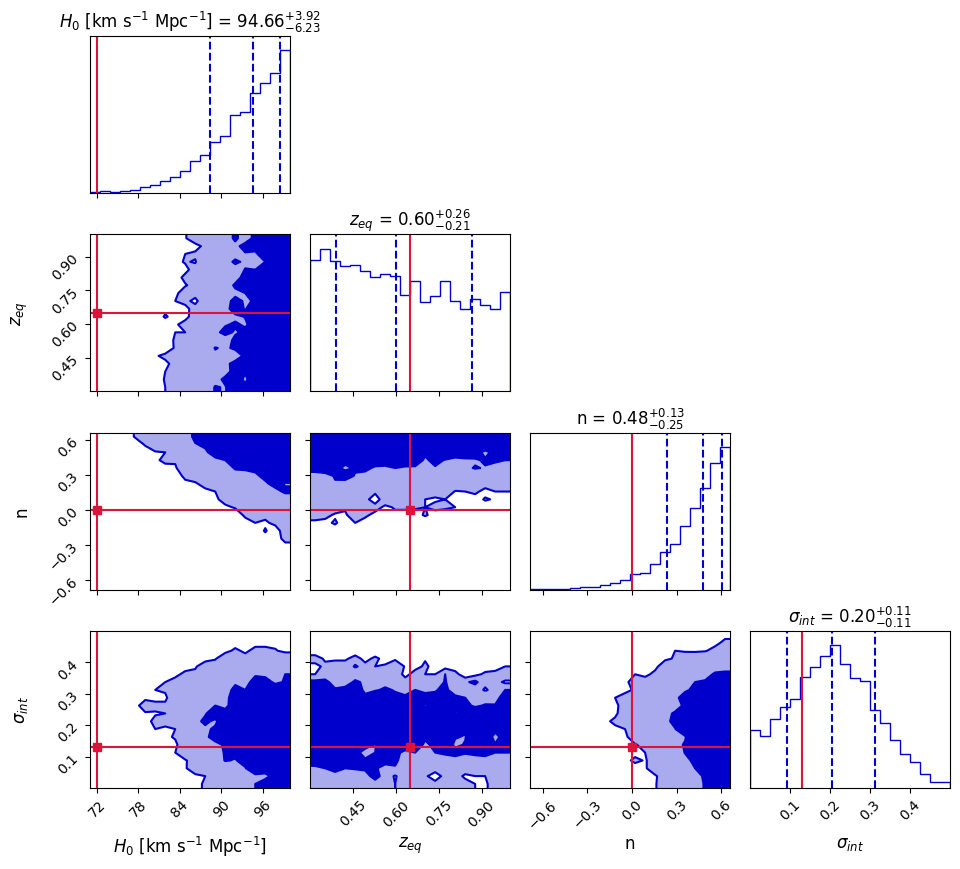

<Figure size 640x480 with 0 Axes>

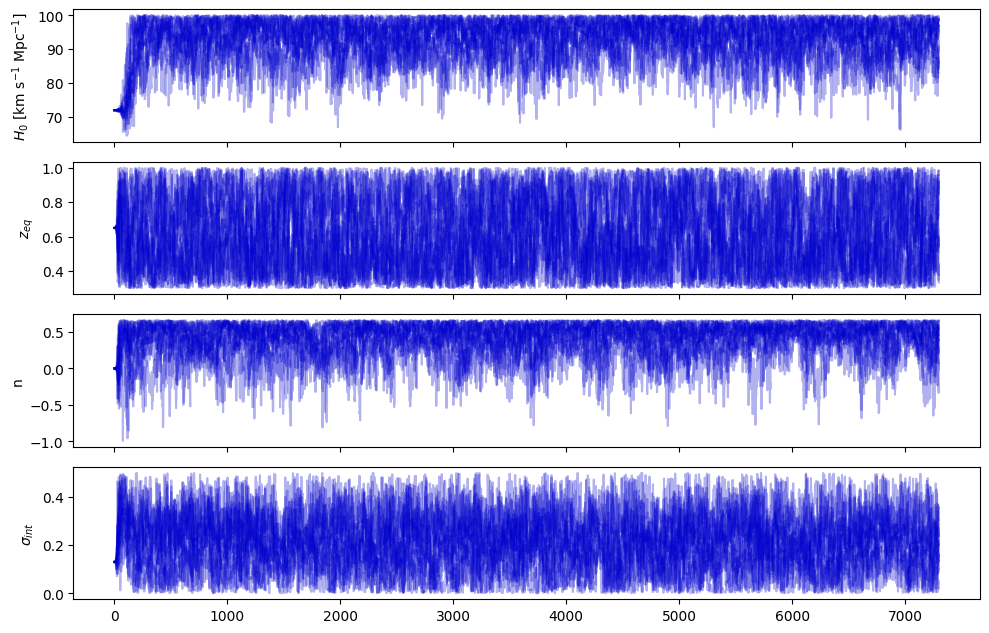

Autocorrelation times: [105.99697563  89.49299647 101.96474357  70.18214259]


In [ ]:
def expansion_rate(z, z_eq, n):              # Freese 2002
  num_term = np.sqrt((1+z)**3 + (1+z_eq)**(3*(1-n)) * (1+z)**(3*n))
  den_term = np.sqrt(1 + (1+z_eq)**(3*(1-n)))
  return num_term / den_term

def theo_DA_Cardassian(H0, z, z_eq, n):        # Freese 2002
  integral = lambda zeta: 1 / expansion_rate(zeta, z_eq, n)
  term_num = c * quad(integral, 0, z)[0]   # Integration by the Scipy module quad
  term_den = H0 * (1+z)
  da_theo = term_num / term_den                         # [Mpc]
  return da_theo / 1000                                         # [Gpc]

def lnlike(theta, z_vals, DA_obs, DA_err):
    H0, z_eq, n, sigma_int = theta
    DA_model = np.array([theo_DA_Cardassian(H0, zi, z_eq, n) for zi in z_vals])
    total_err2 = DA_err**2 + (sigma_int * DA_model)**2
    chi2 = np.sum((DA_obs - DA_model)**2 / total_err2)
    return -0.5 * (chi2 + np.sum(np.log(2 * np.pi * total_err2)))

def lnprior(theta):
    H0, z_eq, n, sigma_int = theta
    # Priors based on Freese 2002: n < 2/3 for acceleration
    if 40 < H0 < 100 and 0.3 < z_eq < 1.0 and -1.0 < n < 0.66 and 0.0 < sigma_int < 0.5:
        return 0.0
    return -np.inf

def lnprob(theta, z_vals, DA_obs, DA_err): # Metropolis-Hastings criterion
    lp = lnprior(theta)
    if not np.isfinite(lp):
        return -np.inf
    return lp + lnlike(theta, z_vals, DA_obs, DA_err)

ndim = 4                                      # Number of dimensions in the parameter space
nwalkers = 16                               # The number of walkers in the ensemble
initial = np.array([72, 0.65, 0.0, 0.13])            # Initial guess around LCDM
pos = initial + 1e-4 * np.random.randn(nwalkers, ndim)

z_vals = np.asarray(z)

sampler = emcee.EnsembleSampler(
    nwalkers, ndim, lnprob,
    args=(z_vals, DA_calc, DA_err_total))

sampler.run_mcmc(pos, 7300, progress=True)
samples = sampler.get_chain(discard=1060, thin=15, flat=True)

#
H0_samples, zeq_samples, n_samples, sigma_samples = samples[:,0], samples[:,1], samples[:,2], samples[:,3]

F_samples = 1.0 / (1.0 + (1.0 + zeq_samples)**(3.0 * (1.0 - n_samples)))
F_median = np.median(F_samples)
F_lower, F_upper = np.percentile(F_samples, [16, 84])

# Report results using median and 16th/84th percentiles as Bonamente 2006
print(f"H0 = {np.median(H0_samples):.2f} +/- {np.percentile(H0_samples, [16, 84]) - np.median(H0_samples)}")
print(f"z_eq = {np.median(zeq_samples):.2f} +/- {np.percentile(zeq_samples, [16, 84]) - np.median(zeq_samples)}")
print(f"n = {np.median(n_samples):.2f} +/- {np.percentile(n_samples, [16, 84]) - np.median(n_samples)}")
print(f"sigma_int = {np.median(sigma_samples):.2f} +/- {np.percentile(sigma_samples, [16, 84]) - np.median(sigma_samples)}")
print(f"F (Density Ratio) = {F_median:.3f} +{F_upper - F_median:.3f} / -{F_median - F_lower:.3f}")

# Corner Plot
plt.figure(figsize=(8, 8))
labels = [r"$H_0$ [km s$^{-1}$ Mpc$^{-1}$]", r"$z_{eq}$", r"n", r"$\sigma_{int}$"]
fig = corner.corner(samples, labels=labels, truths=[72, 0.65, 0.0, 0.13], show_titles=True,
    title_fmt=".2f", quantiles=[0.16, 0.5, 0.84], levels=(0.68, 0.95), color="mediumblue",
    truth_color="crimson", plot_datapoints=False, fill_contours=True, label_kwargs={"fontsize": 12})
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

##  Convergence test
  # We want the walkers to look like a "fuzzy caterpillar" (http://phoebe-project.org/, PHOEBE tutorial emcee.ipynb)
plt.figure()
fig, axes = plt.subplots(ndim, figsize=(10, 7), sharex=True)
for i in range(ndim):
    ax = axes[i]
    ax.plot(sampler.get_chain()[:, :, i], "mediumblue", alpha=0.3)
    ax.set_ylabel(labels[i])
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# We want our chain to be at least 50 times longer than the autocorrelation time (http://phoebe-project.org/, PHOEBE tutorial emcee.ipynb)
tau = sampler.get_autocorr_time()
print(f"Autocorrelation times: {tau}")